# CSM by Example

To start, we'll import the relevant packages for the whole demonstration. For a more complete
definition of all that is made available for each model, please see the
[`CSMBase` (base model) documentation](#api:base-model), or any of the other available models.

In [1]:
import numpy as np
import pandas as pd

from csm import get_model, Land2015NLR, available_models
from csm.tools import plot

pd.options.display.float_format = "{:,.2f}".format

## What Models Are Available and How Do I Set Them Up?

For absolute beginners, we can see which models are available by printing `available_models`.

In [2]:
print(available_models)

('CSMBase', 'Land2015NLR', 'Land2020NLR', 'Land2021NLR')


For users that don't want to deal with importing multiple models, simply retrieve them with
`get_model()`, which makes a series of aliases available for convenience.

In [3]:
assert (
    Land2015NLR
    == get_model(2015)
    == get_model("land-2015")
    == get_model("nlr-2015")
    == get_model("NLR 2015")
)

Now that we have a variety of convenient means for accessing available models, we can also print out
the minimum required inputs to run the model.

In [4]:
nlr2015 = get_model("2015")
print(nlr2015.get_required_inputs())

['turbine_class', 'rated_power_kw', 'rotor_diameter', 'num_bearings', 'blade_has_carbon', 'max_tip_speed', 'tower_length']


Also available with units.

In [5]:
print(Land2015NLR.get_required_inputs(include_units=True))

[('turbine_class', 'unitless'), ('rated_power_kw', 'kW'), ('rotor_diameter', 'm'), ('num_bearings', 'unitless'), ('blade_has_carbon', 'unitless'), ('max_tip_speed', 'm/s'), ('tower_length', 'm')]


## Replicating Results from the 2015 WISDEM/Excel Model

The `Land2015NLR` model is based on teh WISDEM implementation of the CSM, and the configuration
dictionary is also based on the WISDEM example. To create the model itself, we use
the `from_dict` method to pass a configuration dictionary, which has additional error handling
to better guide users if their configurations fail to initialize a model.

In [6]:
wisdem_test_inputs = {
    "turbine_class": 1,
    "efficiency_max": 0.9,
    "num_blades": 3,
    "num_bearings": 2,
    "rated_power_kw": 5000,
    "blade_has_carbon": False,
    "has_crane": True,
    "rotor_diameter": 126,
    "max_tip_speed": 80,
    "tower_length": 90,
}

nlr2015 = Land2015NLR.from_dict(wisdem_test_inputs)
nlr2015.run()
print(f"Turbine cost (USD/kW): ${nlr2015.turbine_cost_kw:,.2f}")

Turbine cost (USD/kW): $686.00


For incomplete configurations, this approach will fail, as shown below. However, if we add
`partial=True`, a partial model can be defined. This is useful for parameter sweeps or calculating
a limited number of component values.

In [7]:
partial_inputs = {
    "turbine_class": 1,
    "num_blades": 3,
    "rated_power_kw": 5000,
    "blade_has_carbon": False,
    "rotor_diameter": 126,
    "max_tip_speed": 80,
}

partial2015 = Land2015NLR.from_dict(partial_inputs)

AttributeError: The class definition for Land2015NLR is missing the following inputs: tower_length, num_bearings

Now, using `partial=True`, we can create an incomplete model and get the results we desire.

In [8]:
partial2015 = Land2015NLR.from_dict(wisdem_test_inputs, partial=True)
partial2015.calculate("blade_mass", "blade_cost")
print(f"Single blade mass (kg): {partial2015.blade_mass:,.2f}")
print(f"Single blade cost (thousands, USD): ${partial2015.blade_cost / 1000:,.2f}")

Single blade mass (kg): 18,590.67
Single blade cost (thousands, USD): $271.42


## Getting Results

### Single Model Runs

For basic dictionary outputs, any of [`get_results`](#csm.models.CSMBase.get_results),
[`get_mass_results`](#csm.models.CSMBase.get_mass_results),
[`get_cost_results`](#csm.models.CSMBase.get_cost_results), or
[`get_all_results`](#csm.models.CSMBase.get_all_results). Below, we demonstrate retrieving the blade
results.

In [9]:
nlr2015.get_results(["blade_mass", "blade_cost"])

{'blade_mass': 18590.668206489747, 'blade_cost': 271423.7558147503}

For a more complete breakdown, we can also get a DataFrame of all the major mass and cost results.

In [10]:
df = nlr2015.get_component_breakdown()
df["Cost (USD)"] /= 1000
df = df.rename(columns={"Cost (USD)": "Cost (thousands USD)"})
df

,Mass (kg),Cost (thousands USD)
Component,,
bearing,"2,245.42",10.10
bedplate,"41,765.26",121.12
blade,"18,590.67",271.42
blade_transport,NaN,0.00
brake,"5,337.50",19.35
controls,0.00,105.75
converter,0.00,0.00
drivetrain_transport,NaN,0.00
electrical_connection,0.00,209.25


#### IRS Domestic Content Tables

For helping with calculating the total domestic content, both `irs_mpc_breakdown` and
`total_domestic_content` are made available. Note that in both the below examples, the data are
purely expository.

In [11]:
nlr2015.irs_mpc_breakdown(
    turbine_production_cost=1500,
    tower_flange_material_cost=2000,
    tower_flange_production_cost=1000,
)

cost  Value
APC                                  MPC                                
Wind Turbine                         Blade             814,271.27  28.02
                                     Rotor Hub         421,362.42  14.50
                                     Nacelle         1,665,612.93  57.32
                                     Power Converter            -      -
                                     Production          1,500.00   0.05
Wind Tower Flange                    Material            2,000.00   0.07
                                     Production          1,000.00   0.03
Tower                                -                          -      -
Steel or iron products in foundation -                          -      -
Total                                -               2,905,746.61 100.00

In [12]:
nlr2015.total_domestic_content(
    turbine_production_cost=1500,
    tower_flange_material_cost=2000,
    tower_flange_production_cost=1000,
    domestic=["tower_flange_material", "tower_flange_production", "nacelle"],
    return_table=True,
)

category  \
APC                                  MPC                                        
Wind Turbine                         Blade                              blade   
                                     Rotor Hub                            hub   
                                     Nacelle                          nacelle   
                                     Power Converter          power_converter   
                                     Production            turbine_production   
Wind Tower Flange                    Material           tower_flange_material   
                                     Production       tower_flange_production   
Tower                                -                                      -   
Steel or iron products in foundation -                                      -   
Total                                -                                      -   

                                                             cost  Value  \
APC                                  MPC                                   
Wind Turbine                         Blade             814,271.27  28.02   
                                     Rotor Hub         421,362.42  14.50   
                                     Nacelle         1,665,612.93  57.32   
                                     Power Converter         0.00   0.00   
                                     Production          1,500.00   0.05   
Wind Tower Flange                    Material            2,000.00   0.07   
                                     Production          1,000.00   0.03   
Tower                                -                       0.00   0.00   
Steel or iron products in foundation -                       0.00   0.00   
Total                                -               2,905,746.61 100.00   

                                                     Domestic  
APC                                  MPC                       
Wind Turbine                         Blade               0.00  
                                     Rotor Hub           0.00  
                                     Nacelle             0.00  
                                     Power Converter     0.00  
                                     Production          0.00  
Wind Tower Flange                    Material            0.07  
                                     Production          0.03  
Tower                                -                   0.00  
Steel or iron products in foundation -                   0.00  
Total                                -                   0.10

## Parameter Sweeps

For experimental designs to understand tradeoffs in cost and mass, users can run parameter sweeps
using either the [`parameterize`](#csm.models.CSMBase.parameterize) or
[`parameterize_subset`](#csm.models.CSMBase.parameterize_subset). For `parameterize`, the entire
model is run, but for `parameterize_subset` only a single input can be parameterized.

Note that in the below example, the model does not have to be created first. Additionally, we can
provide parameterizations as either a "range" of inputs defining the minimum value, maximum value,
and the number of points to generate in between them, or the "inputs," which uses the values as
provided.

In [13]:
parameters = {
    "max_tip_speed": ("range", 80, 90, 3),
    "tower_length": ("inputs", 80, 110),
}
results = ["nacelle_mass", "nacelle_cost", "tower_mass", "tower_cost", "turbine_cost_kw"]
Land2015NLR.parameterize(
    base_kwargs=wisdem_test_inputs, parameterized_kwargs=parameters, results=results
)

max_tip_speed          80.00                     85.00               \
tower_length             80           110          80           110   
nacelle_cost    1,665,612.93 1,665,612.93 1,651,607.01 1,651,607.01   
nacelle_mass      151,455.88   151,455.88   149,855.15   149,855.15   
tower_cost        416,412.75   794,382.29   416,412.75   794,382.29   
tower_mass        143,590.60   273,924.93   143,590.60   273,924.93   
turbine_cost_kw       663.53       739.13       660.73       736.32   

max_tip_speed          90.00               
tower_length             80           110  
nacelle_cost    1,639,157.31 1,639,157.31  
nacelle_mass      148,432.27   148,432.27  
tower_cost        416,412.75   794,382.29  
tower_mass        143,590.60   273,924.93  
turbine_cost_kw       658.24       733.83

## Plotting

### Mass vs Cost Comparison for a Single Parameter Sweep

In the following example, we use each of the available models to create their cost and scaling
curves for a single rotor blade as we modify the rotor diameter. We additionally, plot 2 ATB
reference turbines and 3 industry reference turbines as examples for each of the models. Finally,
we add some synthetic empirical data to visually inspect how the curves fit the empirical data.

In addition to the model and data inputs, we can provide many formatting arguments to control
display elements such as the line colors, reference turbine markers, empirical data scatter markers,
axis limits, and legend formatting.

Please see the [`plot_mass_cost_comparison` documentation](#csm.tools.plot.plot_mass_cost_comparison)
for full details on available settings.

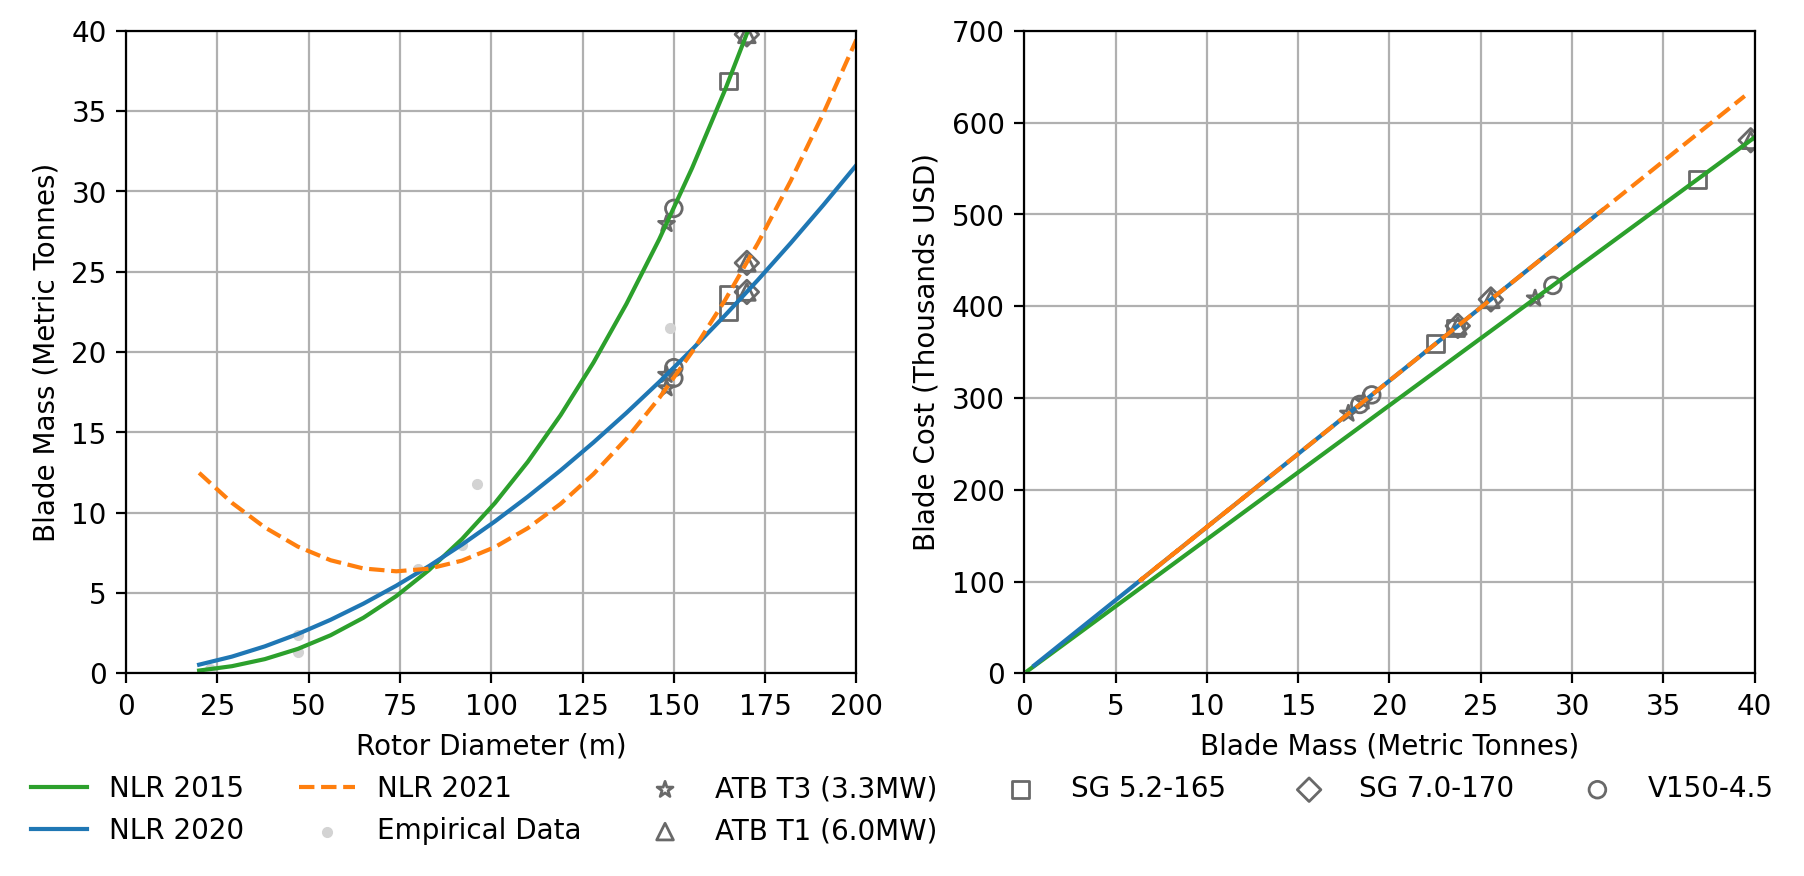

In [14]:
model_base = {
    "NLR 2015": {"turbine_class": 1, "blade_has_carbon": False},
    "NLR 2020": {},
    "NLR 2021": {},
}
parameterization = {"rotor_diameter": ["range", 20, 200, 21]}
reference_turbs = {
    "ATB T3 (3.3MW)": {
        "rated_power_kw": 3300,
        "rotor_diameter": 148.0,
        "tower_length": 100,
        "max_tip_speed": 90,
        "num_bearings": 1,
        "num_blades": 3,
        "efficiency_max": 0.9,
        "turbine_class": 1,
        "blade_has_carbon": False,
    },
    "ATB T1 (6.0MW)": {
        "rated_power_kw": 6000,
        "rotor_diameter": 170.0,
        "tower_length": 115.0,
        "max_tip_speed": 90.0,
        "num_bearings": 1,
        "num_blades": 3,
        "efficiency_max": 0.9,
        "turbine_class": 1,
        "blade_has_carbon": False,
    },
    "SG 5.2-165": {
        "rated_power_kw": 5200,
        "rotor_diameter": 165.0,
        "tower_length": 105.0,
        "max_tip_speed": 90.0,
        "num_bearings": 1,
        "num_blades": 3,
        "efficiency_max": 0.9,
        "turbine_class": 1,
        "blade_has_carbon": False,
    },
    "SG 7.0-170": {
        "rated_power_kw": 7000,
        "rotor_diameter": 170.0,
        "tower_length": 135.0,
        "max_tip_speed": 90.0,
        "num_bearings": 1,
        "num_blades": 3,
        "efficiency_max": 0.9,
        "turbine_class": 1,
        "blade_has_carbon": False,
    },
    "V150-4.5": {
        "rated_power_kw": 4500,
        "rotor_diameter": 150.0,
        "tower_length": 105.0,
        "max_tip_speed": 82.0,
        "num_bearings": 1,
        "num_blades": 3,
        "efficiency_max": 0.9,
        "turbine_class": 1,
        "blade_has_carbon": False,
    },
}
data = [
    [47, 2400, np.nan],
    [47, 1300, np.nan],
    [23, 300, np.nan],
    [80, 6500, np.nan],
    [149, 21500, np.nan],
    [92, 8000, np.nan],
    [96.1, 11800, np.nan],
]
empirical_data = pd.DataFrame(data, columns=["rotor_diameter", "blade_mass", "blade_cost"])

model_line_fmt = {
    "NLR 2020": {"c": "tab:blue"},
    "NLR 2021": {"c": "tab:orange", "ls": "dashed"},
    "NLR 2015": {"c": "tab:green"},
}
turbine_formatting = {
    "ATB T3 (3.3MW)": {"marker": "*"},
    "ATB T1 (6.0MW)": {"marker": "^"},
    "SG 5.2-165": {
        "marker": "s",
    },
    "SG 7.0-170": {
        "marker": "D",
    },
    "V150-4.5": {
        "marker": "o",
    },
}
legend_formatting = {
    "loc": "outside lower center",
    "ncols": 6,
    "bbox_to_anchor": (0.5, -0.1),
    "frameon": False,
}

plot.plot_mass_cost_comparison(
    base_kwargs=model_base,
    parameterization=parameterization,
    component="blade",
    parameter_label="Rotor Diameter (m)",
    cost_basis="thousands",
    reference_turbines=reference_turbs,
    background_data=empirical_data,
    mass_xlim=(0, 200),
    mass_ylim=(0, 40),
    cost_xlim=(0, 40),
    cost_ylim=(0, 700),
    model_plot_settings=model_line_fmt,
    turbine_scatter_settings=turbine_formatting,
    reference_scatter_kwargs={"c": "none", "edgecolor": "dimgray"},
    background_scatter_kwargs={"marker": ".", "c": "lightgray"},
    legend_kwargs=legend_formatting,
)